# Research Question 2: Intra-Team Performance Dynamics

**ST312 Project - Candidates: 60276, 61881**

## Research Question
*"Does statistical evidence from lap times, pit stop timing, and tyre allocation indicate systematic performance differences between teammates within Formula 1 teams?"*

## Context
F1 teams field two drivers but have limited resources. Public perception exists that teams may favor championship contenders over supporting drivers through:
- Better/newer car parts and upgrades
- Faster pit stop service
- Preferential tyre compound allocation
- Strategic priority in race situations

## Approach
This notebook focuses on **exploratory data analysis** through visualization:
- Load lap-by-lap timing data for 2022-2024
- Compare lap time distributions between teammates
- Analyze pit stop duration differences
- Examine tyre compound and stint strategy allocation
- Visualize team-by-team performance gaps

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import data_utils as du

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

Load lap-by-lap timing data including tyre information for 2022-2024 seasons.

In [2]:
# Define years to analyze
YEARS = [2022, 2023, 2024]

# Load lap timing data (this may take 15-25 minutes on first run)
print("Loading lap timing data for teammate analysis...")
print("Note: First run will download and cache extensive lap-by-lap data.")
print("This is significantly more data than RQ1.\n")

laps_df = du.load_teammate_data(YEARS)

Loading lap timing data for teammate analysis...
Note: First run will download and cache extensive lap-by-lap data.
This is significantly more data than RQ1.


Loading 2022 season lap data...
  Processing Bahrain Grand Prix... 

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand P

✓
  Processing Saudi Arabian Grand Prix... 

core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core       

✓
  Processing Australian Grand Prix... 

...

✓
  Processing Qatar Grand Prix... 

req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

✓
  Processing Abu Dhabi Grand Prix... 

req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written t

✓

Loaded 64479 lap observations


In [3]:
# Display data summary
du.print_data_summary(laps_df, "RQ2: Lap Timing Data Summary")

print("Sample data:")
laps_df.head(10)


RQ2: Lap Timing Data Summary
Total observations: 64479
Date range: 2022 - 2024
Number of unique races: 25
Number of unique drivers: 28
Number of unique teams: 12

Sample data:


,year,race,driver,team,lap_number,lap_time,compound,tyre_life,stint,track_status,is_personal_best
0,2022,Bahrain Grand Prix,VER,Red Bull Racing,2.0,97.880,SOFT,5.0,1.0,1,True
1,2022,Bahrain Grand Prix,VER,Red Bull Racing,3.0,98.357,SOFT,6.0,1.0,1,False
2,2022,Bahrain Grand Prix,VER,Red Bull Racing,4.0,98.566,SOFT,7.0,1.0,1,False
3,2022,Bahrain Grand Prix,VER,Red Bull Racing,5.0,98.877,SOFT,8.0,1.0,1,False
4,2022,Bahrain Grand Prix,VER,Red Bull Racing,6.0,98.940,SOFT,9.0,1.0,1,False
5,2022,Bahrain Grand Prix,VER,Red Bull Racing,7.0,99.062,SOFT,10.0,1.0,1,False
6,2022,Bahrain Grand Prix,VER,Red Bull Racing,8.0,99.092,SOFT,11.0,1.0,1,False
7,2022,Bahrain Grand Prix,VER,Red Bull Racing,9.0,99.251,SOFT,12.0,1.0,1,False
8,2022,Bahrain Grand Prix,VER,Red Bull Racing,10.0,99.392,SOFT,13.0,1.0,1,False
9,2022,Bahrain Grand Prix,VER,Red Bull Racing,11.0,99.479,SOFT,14.0,1.0,1,False


In [4]:
# Load pit stop data
print("\nLoading pit stop data...")
pitstops_df = du.get_pit_stop_data(YEARS)

print(f"\nPit stop data loaded: {len(pitstops_df)} pit stops")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



Loading pit stop data...

Loading 2022 pit stop data...
  Processing Bahrain Grand Prix... 

req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core  

✓
  Processing Saudi Arabian Grand Prix... 

core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core       

...

✓
  Processing Qatar Grand Prix... 

core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


✓
  Processing Abu Dhabi Grand Prix... 

req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


✓

Loaded 2538 pit stop observations

Pit stop data loaded: 2538 pit stops


## 2. Identify Teammate Pairs

Determine which drivers are teammates for meaningful comparisons.

In [5]:
# Get teammate pairs
team_pairs = du.get_team_pairs(laps_df)

print("Teammate Pairs (2022-2024)")
print("="*60)
for team, drivers in sorted(team_pairs.items()):
    print(f"{team:30s}: {', '.join(sorted(drivers))}")

print(f"\nTotal teams: {len(team_pairs)}")

Teammate Pairs (2022-2024)
Alfa Romeo                    : BOT, ZHO
AlphaTauri                    : DEV, GAS, LAW, RIC, TSU
Alpine                        : ALO, DOO, GAS, OCO
Aston Martin                  : ALO, HUL, STR, VET
Ferrari                       : BEA, LEC, SAI
Haas F1 Team                  : BEA, HUL, MAG, MSC
Kick Sauber                   : BOT, ZHO
McLaren                       : NOR, PIA, RIC
Mercedes                      : HAM, RUS
RB                            : LAW, RIC, TSU
Red Bull Racing               : PER, VER
Williams                      : ALB, COL, DEV, LAT, SAR

Total teams: 12


## 3. Lap Time Analysis

Compare lap time distributions between teammates to identify systematic differences.

In [6]:
# Filter to valid lap times only
valid_laps = laps_df[laps_df['lap_time'].notna()].copy()

# Calculate average lap time by driver
driver_avg_times = valid_laps.groupby(['driver', 'team'])['lap_time'].agg(['mean', 'std', 'count']).reset_index()
driver_avg_times = driver_avg_times.sort_values('mean')

print("Top 10 Fastest Average Lap Times (All Laps)")
print("="*70)
print(driver_avg_times.head(10).to_string(index=False))

print("\nBottom 10 Slowest Average Lap Times")
print("="*70)
print(driver_avg_times.tail(10).to_string(index=False))

Top 10 Fastest Average Lap Times (All Laps)
driver            team      mean       std  count
   DEV      AlphaTauri 86.364957 10.183539    493
   DEV        Williams 87.328333  0.424756     42
   PIA         McLaren 87.770492  9.933695   2317
   SAI         Ferrari 88.278846 10.832399   3164
   VER Red Bull Racing 88.380715 10.948689   3448
   RIC              RB 88.410367 10.799034    894
   HAM        Mercedes 88.501032 10.939850   3349
   LEC         Ferrari 88.903641 10.943078   3254
   NOR         McLaren 88.923921 11.154840   3442
   ZHO     Kick Sauber 88.927658  9.514264   1177

Bottom 10 Slowest Average Lap Times
driver         team      mean       std  count
   GAS   AlphaTauri 90.714491 12.542427   1030
   LAT     Williams 90.746732 11.508701    956
   RIC   AlphaTauri 90.988323 11.647762    371
   LAW   AlphaTauri 91.139340  8.481134    244
   MSC Haas F1 Team 91.678367 12.753760    946
   RIC      McLaren 91.774409 12.542479   1008
   BEA      Ferrari 94.031696  1.415408 

In [7]:
# Calculate teammate lap time differences
teammate_diffs = []

for team, drivers in team_pairs.items():
    if len(drivers) < 2:
        continue
    
    for i in range(len(drivers)):
        for j in range(i+1, len(drivers)):
            driver1, driver2 = drivers[i], drivers[j]
            
            d1_laps = valid_laps[valid_laps['driver'] == driver1]['lap_time']
            d2_laps = valid_laps[valid_laps['driver'] == driver2]['lap_time']
            
            if len(d1_laps) > 0 and len(d2_laps) > 0:
                diff = d1_laps.mean() - d2_laps.mean()
                
                teammate_diffs.append({
                    'team': team,
                    'driver1': driver1,
                    'driver2': driver2,
                    'driver1_mean': d1_laps.mean(),
                    'driver2_mean': d2_laps.mean(),
                    'time_diff_sec': diff,
                    'faster_driver': driver1 if diff < 0 else driver2,
                    'n_laps_d1': len(d1_laps),
                    'n_laps_d2': len(d2_laps)
                })

teammate_diff_df = pd.DataFrame(teammate_diffs)

print("\nTeammate Lap Time Differences (Larger gap = more unequal)")
print("="*80)
print(teammate_diff_df.sort_values('time_diff_sec', key=abs, ascending=False).to_string(index=False))


Teammate Lap Time Differences (Larger gap = more unequal)
           team driver1 driver2  driver1_mean  driver2_mean  time_diff_sec faster_driver  n_laps_d1  n_laps_d2
       Williams     DEV     COL     86.440587     94.247896      -7.807309           DEV        535        356
        Ferrari     SAI     BEA     88.278846     95.481013      -7.202168           SAI       3164        150
        Ferrari     LEC     BEA     88.903641     95.481013      -6.577372           LEC       3254        150
   Haas F1 Team     HUL     BEA     90.459040     95.481013      -5.021973           HUL       2311        150
   Haas F1 Team     MAG     BEA     90.588738     95.481013      -4.892275           MAG       3073        150
       Williams     SAR     COL     89.640868     94.247896      -4.607028           SAR       1686        356
       Williams     ALB     COL     89.822337     94.247896      -4.425560           ALB       2930        356
       Williams     LAT     DEV     90.746732     86.

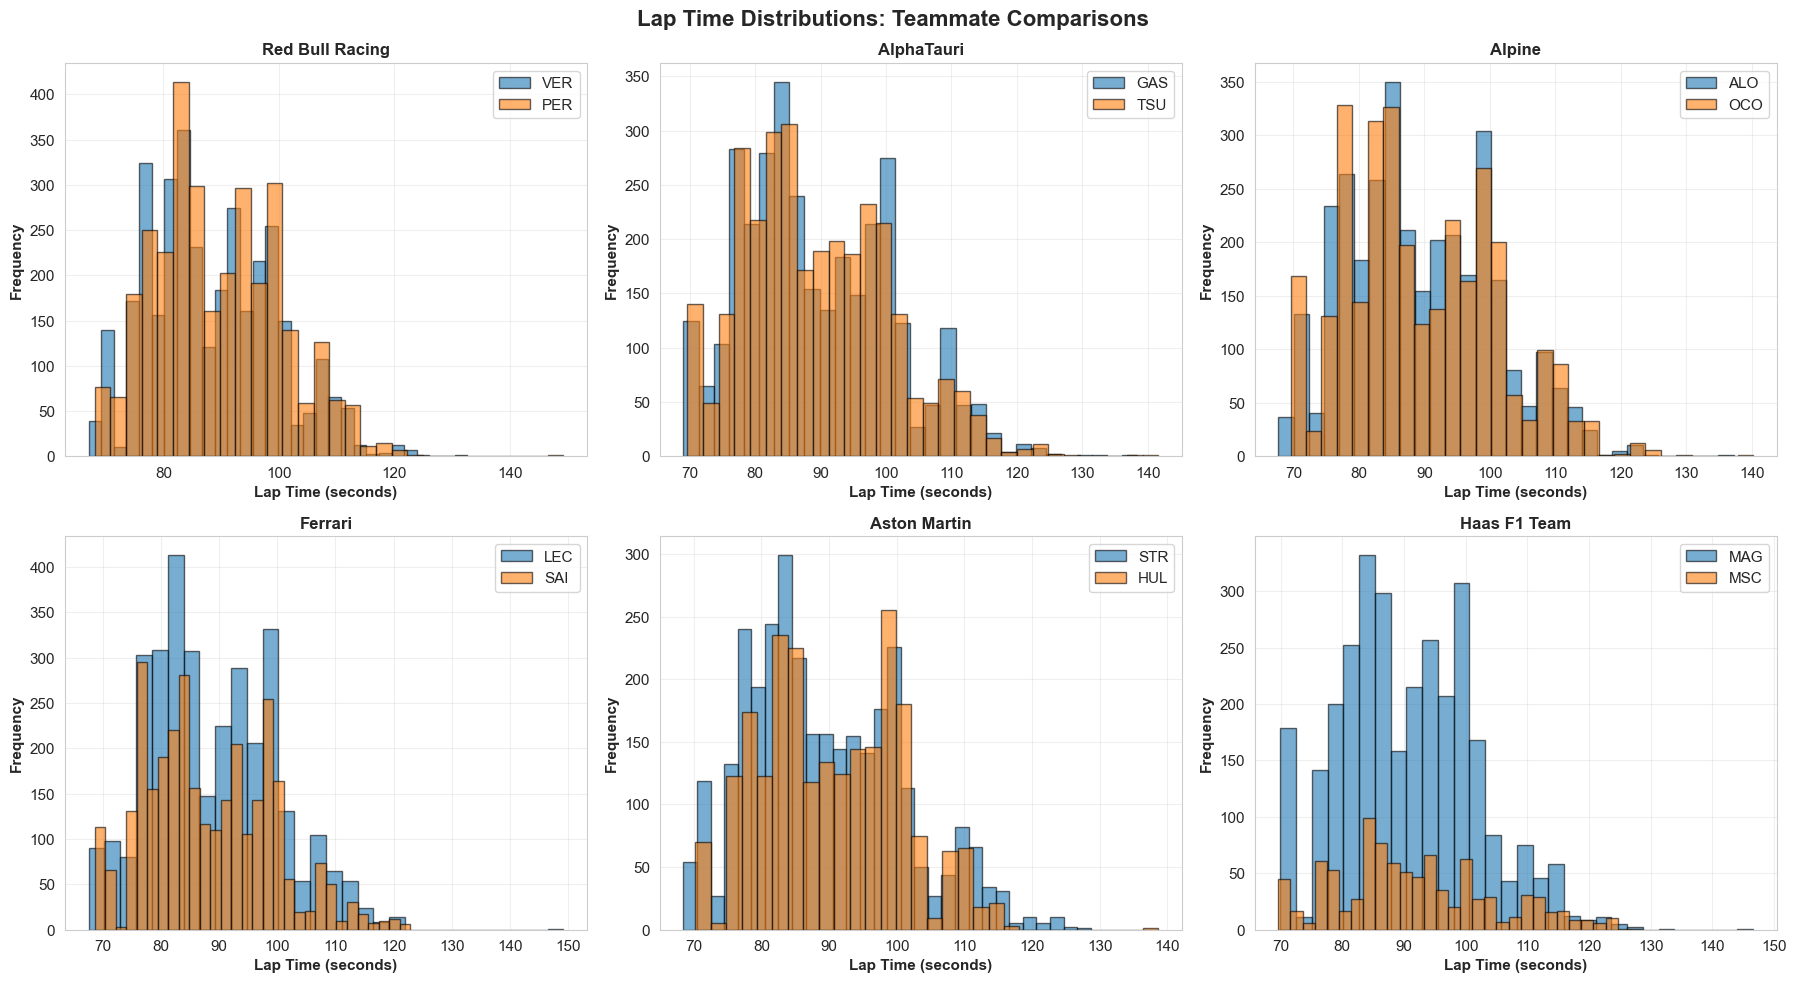

In [8]:
# Visualize teammate comparisons for selected teams
# Select 6 representative teams for visualization
selected_teams = list(team_pairs.keys())[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, team in enumerate(selected_teams):
    if idx >= 6:
        break
        
    drivers = team_pairs[team]
    if len(drivers) < 2:
        continue
    
    for driver in drivers[:2]:  # Only first 2 teammates
        driver_laps = valid_laps[valid_laps['driver'] == driver]['lap_time']
        axes[idx].hist(driver_laps, bins=30, alpha=0.6, label=driver, edgecolor='black')
    
    axes[idx].set_xlabel('Lap Time (seconds)', fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontweight='bold')
    axes[idx].set_title(f'{team}', fontweight='bold', fontsize=12)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Lap Time Distributions: Teammate Comparisons', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

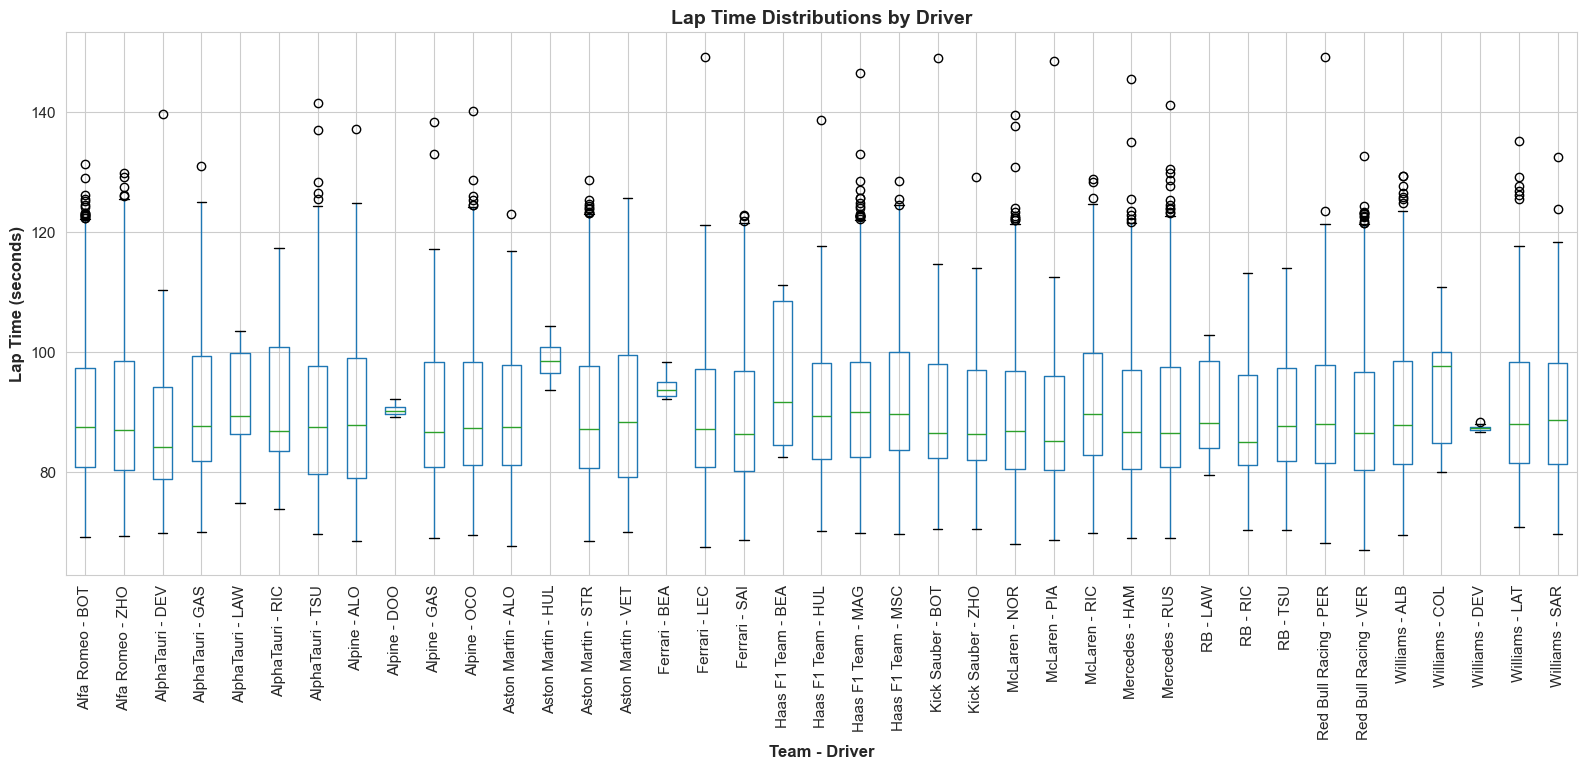

In [9]:
# Box plot comparison for all teams
fig, ax = plt.subplots(figsize=(16, 8))

# Prepare data for box plot
valid_laps['team_driver'] = valid_laps['team'] + ' - ' + valid_laps['driver']
valid_laps_sorted = valid_laps.sort_values(['team', 'driver'])

# Create box plot
valid_laps_sorted.boxplot(column='lap_time', by='team_driver', ax=ax, rot=90, figsize=(16, 8))
ax.set_xlabel('Team - Driver', fontsize=12, fontweight='bold')
ax.set_ylabel('Lap Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Lap Time Distributions by Driver', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove auto title

plt.tight_layout()
plt.show()

## 4. Pit Stop Analysis

Compare pit stop durations and timing between teammates to identify potential favoritism.

In [10]:
# Note: Pit stop duration is complex to extract from FastF1
# Instead, we'll analyze pit stop timing (which lap) and frequency

if len(pitstops_df) > 0:
    # Pit stop statistics by driver
    pitstop_stats = pitstops_df.groupby(['driver', 'team']).agg({
        'lap_number': ['count', 'mean'],
        'stint': 'max'
    }).reset_index()
    
    pitstop_stats.columns = ['driver', 'team', 'num_pitstops', 'avg_pitstop_lap', 'max_stint']
    pitstop_stats = pitstop_stats.sort_values('num_pitstops', ascending=False)
    
    print("Pit Stop Statistics by Driver")
    print("="*80)
    print(pitstop_stats.head(15).to_string(index=False))
else:
    print("No pit stop data available for analysis.")

Pit Stop Statistics by Driver
driver            team  num_pitstops  avg_pitstop_lap  max_stint
   PER Red Bull Racing           139        28.827338        7.0
   VER Red Bull Racing           135        30.037037        7.0
   NOR         McLaren           135        28.962963        7.0
   STR    Aston Martin           133        26.481203        8.0
   RUS        Mercedes           131        29.229008        8.0
   HAM        Mercedes           125        28.784000        6.0
   MAG    Haas F1 Team           120        26.083333        7.0
   LEC         Ferrari           119        27.512605        5.0
   ALB        Williams           116        26.827586        5.0
   OCO          Alpine           115        27.573913        7.0
   SAI         Ferrari           115        28.756522        6.0
   HUL    Haas F1 Team            95        25.936842        6.0
   TSU      AlphaTauri            91        27.186813        6.0
   ALO    Aston Martin            90        28.011111       

In [11]:
# Compare pit stop frequency between teammates
if len(pitstops_df) > 0:
    teammate_pitstop_comparison = []
    
    for team, drivers in team_pairs.items():
        if len(drivers) < 2:
            continue
        
        for i in range(len(drivers)):
            for j in range(i+1, len(drivers)):
                driver1, driver2 = drivers[i], drivers[j]
                
                d1_stops = pitstops_df[pitstops_df['driver'] == driver1]
                d2_stops = pitstops_df[pitstops_df['driver'] == driver2]
                
                if len(d1_stops) > 0 and len(d2_stops) > 0:
                    teammate_pitstop_comparison.append({
                        'team': team,
                        'driver1': driver1,
                        'driver2': driver2,
                        'd1_stops': len(d1_stops),
                        'd2_stops': len(d2_stops),
                        'stop_diff': len(d1_stops) - len(d2_stops)
                    })
    
    ps_comp_df = pd.DataFrame(teammate_pitstop_comparison)
    
    print("\nTeammate Pit Stop Frequency Comparison")
    print("="*70)
    print(ps_comp_df.to_string(index=False))


Teammate Pit Stop Frequency Comparison
           team driver1 driver2  d1_stops  d2_stops  stop_diff
Red Bull Racing     VER     PER       135       139         -4
     AlphaTauri     GAS     TSU       123       128         -5
     AlphaTauri     GAS     DEV       123        19        104
     AlphaTauri     GAS     RIC       123        84         39
     AlphaTauri     GAS     LAW       123        29         94
     AlphaTauri     TSU     DEV       128        19        109
     AlphaTauri     TSU     RIC       128        84         44
     AlphaTauri     TSU     LAW       128        29         99
     AlphaTauri     DEV     RIC        19        84        -65
     AlphaTauri     DEV     LAW        19        29        -10
     AlphaTauri     RIC     LAW        84        29         55
         Alpine     ALO     OCO       128       115         13
         Alpine     ALO     GAS       128       123          5
         Alpine     ALO     DOO       128         1        127
         Alpine

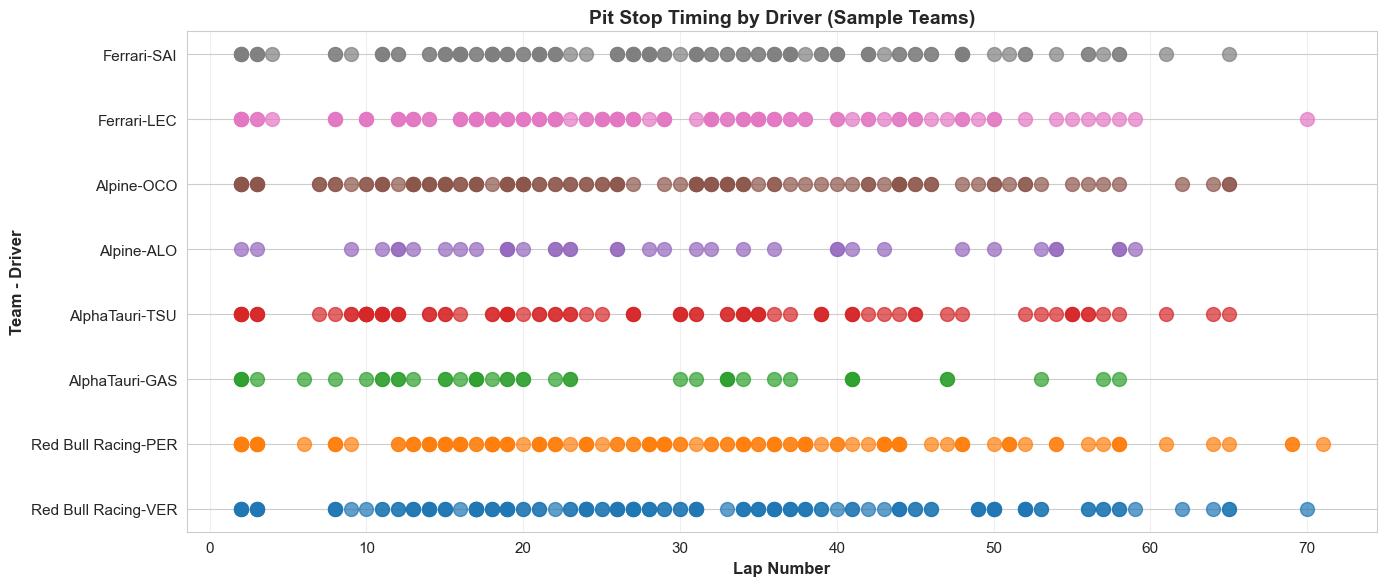

In [12]:
# Visualize pit stop timing (which lap drivers pit)
if len(pitstops_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Sample a few teams for clarity
    sample_teams = list(team_pairs.keys())[:4]
    
    for team in sample_teams:
        team_stops = pitstops_df[pitstops_df['team'] == team]
        
        for driver in team_pairs[team][:2]:
            driver_stops = team_stops[team_stops['driver'] == driver]
            if len(driver_stops) > 0:
                ax.scatter(driver_stops['lap_number'], 
                          [f"{team}-{driver}"] * len(driver_stops),
                          s=100, alpha=0.7, label=f"{team}-{driver}")
    
    ax.set_xlabel('Lap Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Team - Driver', fontsize=12, fontweight='bold')
    ax.set_title('Pit Stop Timing by Driver (Sample Teams)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

## 5. Tyre Allocation Analysis

Examine if teammates receive different tyre compound strategies.

In [13]:
# Filter laps with valid compound data
tyre_laps = laps_df[laps_df['compound'].notna()].copy()

# Count compound usage by driver
compound_usage = tyre_laps.groupby(['driver', 'team', 'compound']).size().reset_index(name='laps')

# Calculate percentage of laps on each compound
total_laps_per_driver = compound_usage.groupby('driver')['laps'].transform('sum')
compound_usage['percentage'] = (compound_usage['laps'] / total_laps_per_driver * 100).round(1)

print("Tyre Compound Usage by Driver (Top 20 by total laps)")
print("="*80)
top_drivers = compound_usage.groupby('driver')['laps'].sum().nlargest(20).index
print(compound_usage[compound_usage['driver'].isin(top_drivers)].to_string(index=False))

Tyre Compound Usage by Driver (Top 20 by total laps)
driver            team     compound  laps  percentage
   ALB        Williams         HARD  1394        47.6
   ALB        Williams INTERMEDIATE   106         3.6
   ALB        Williams       MEDIUM  1064        36.3
   ALB        Williams         None    25         0.9
   ALB        Williams         SOFT   326        11.1
   ALB        Williams          WET    15         0.5
   ALO          Alpine         HARD   404        12.3
   ALO          Alpine INTERMEDIATE    34         1.0
   ALO          Alpine       MEDIUM   375        11.4
   ALO          Alpine         SOFT   105         3.2
   ALO          Alpine          WET    20         0.6
   ALO    Aston Martin         HARD  1114        33.9
   ALO    Aston Martin INTERMEDIATE   138         4.2
   ALO    Aston Martin       MEDIUM   847        25.7
   ALO    Aston Martin         SOFT   253         7.7
   BOT      Alfa Romeo         HARD   968        30.0
   BOT      Alfa Romeo INTERM

In [14]:
# Compare compound usage between teammates
teammate_tyre_comparison = []

for team, drivers in team_pairs.items():
    if len(drivers) < 2:
        continue
    
    for i in range(len(drivers)):
        for j in range(i+1, len(drivers)):
            driver1, driver2 = drivers[i], drivers[j]
            
            d1_tyres = tyre_laps[tyre_laps['driver'] == driver1]
            d2_tyres = tyre_laps[tyre_laps['driver'] == driver2]
            
            if len(d1_tyres) > 0 and len(d2_tyres) > 0:
                # Calculate soft tyre usage percentage
                d1_soft_pct = (d1_tyres['compound'] == 'SOFT').sum() / len(d1_tyres) * 100
                d2_soft_pct = (d2_tyres['compound'] == 'SOFT').sum() / len(d2_tyres) * 100
                
                teammate_tyre_comparison.append({
                    'team': team,
                    'driver1': driver1,
                    'driver2': driver2,
                    'd1_soft_pct': f"{d1_soft_pct:.1f}%",
                    'd2_soft_pct': f"{d2_soft_pct:.1f}%",
                    'soft_diff': f"{d1_soft_pct - d2_soft_pct:.1f}%"
                })

tyre_comp_df = pd.DataFrame(teammate_tyre_comparison)

print("\nTeammate Soft Tyre Usage Comparison")
print("="*80)
print("Note: Soft tyres are fastest but degrade quickly - preferred for qualifying/overtaking")
print(tyre_comp_df.to_string(index=False))


Teammate Soft Tyre Usage Comparison
Note: Soft tyres are fastest but degrade quickly - preferred for qualifying/overtaking
           team driver1 driver2 d1_soft_pct d2_soft_pct soft_diff
Red Bull Racing     VER     PER       13.4%       12.2%      1.2%
     AlphaTauri     GAS     TSU       13.4%       18.8%     -5.4%
     AlphaTauri     GAS     DEV       13.4%       14.4%     -1.0%
     AlphaTauri     GAS     RIC       13.4%       14.3%     -0.9%
     AlphaTauri     GAS     LAW       13.4%        7.1%      6.3%
     AlphaTauri     TSU     DEV       18.8%       14.4%      4.4%
     AlphaTauri     TSU     RIC       18.8%       14.3%      4.5%
     AlphaTauri     TSU     LAW       18.8%        7.1%     11.6%
     AlphaTauri     DEV     RIC       14.4%       14.3%      0.1%
     AlphaTauri     DEV     LAW       14.4%        7.1%      7.2%
     AlphaTauri     RIC     LAW       14.3%        7.1%      7.2%
         Alpine     ALO     OCO       10.9%       11.2%     -0.3%
         Alpine   

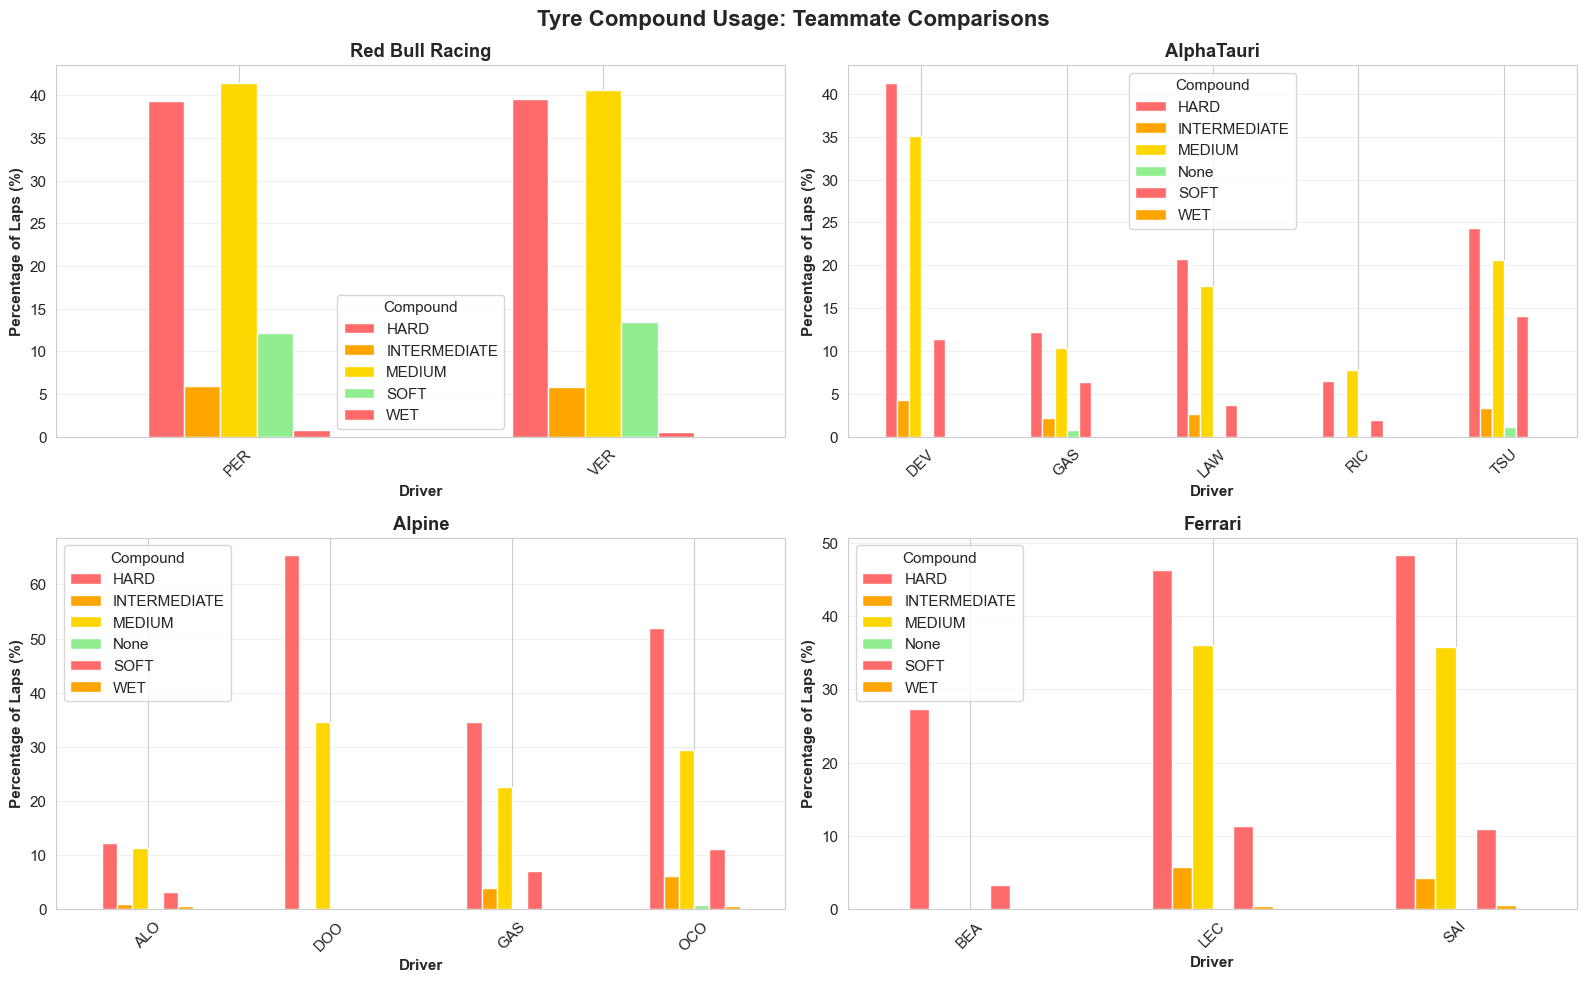

In [15]:
# Visualize compound distribution for selected teams
selected_teams = list(team_pairs.keys())[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, team in enumerate(selected_teams):
    if idx >= 4:
        break
    
    team_data = compound_usage[compound_usage['team'] == team]
    
    # Pivot for grouped bar chart
    pivot_data = team_data.pivot(index='driver', columns='compound', values='percentage').fillna(0)
    
    pivot_data.plot(kind='bar', ax=axes[idx], stacked=False, 
                    color=['#FF6B6B', '#FFA500', '#FFD700', '#90EE90'])
    axes[idx].set_xlabel('Driver', fontweight='bold')
    axes[idx].set_ylabel('Percentage of Laps (%)', fontweight='bold')
    axes[idx].set_title(f'{team}', fontweight='bold')
    axes[idx].legend(title='Compound')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Tyre Compound Usage: Teammate Comparisons', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Stint Length Analysis

Compare how long teammates run on each set of tyres (stint length).

In [16]:
# Calculate stint lengths
stint_lengths = tyre_laps.groupby(['driver', 'team', 'race', 'stint']).size().reset_index(name='stint_length')

# Average stint length by driver
avg_stint = stint_lengths.groupby(['driver', 'team'])['stint_length'].agg(['mean', 'std', 'count']).reset_index()
avg_stint.columns = ['driver', 'team', 'avg_stint_length', 'std_stint', 'num_stints']
avg_stint = avg_stint.sort_values('avg_stint_length', ascending=False)

print("Average Stint Length by Driver")
print("="*80)
print("Longer stints = more conservative strategy, Shorter stints = aggressive pit strategy")
print(avg_stint.head(15).to_string(index=False))

Average Stint Length by Driver
Longer stints = more conservative strategy, Shorter stints = aggressive pit strategy
driver            team  avg_stint_length  std_stint  num_stints
   SAI         Ferrari         41.090909  23.588680          77
   LEC         Ferrari         40.675000  25.039602          80
   VER Red Bull Racing         40.564706  24.066103          85
   NOR         McLaren         40.494118  24.129918          85
   HAM        Mercedes         40.349398  24.087459          83
   RUS        Mercedes         39.569767  24.751252          86
   OCO          Alpine         38.419753  25.845630          81
   MAG    Haas F1 Team         38.412500  23.678594          80
   ALB        Williams         36.172840  25.282796          81
   STR    Aston Martin         35.505618  21.241642          89
   PER Red Bull Racing         35.303371  21.245002          89
   PIA         McLaren         31.310811  19.489320          74
   ALO    Aston Martin         30.153846  18.643670 

In [17]:
# Compare teammate stint strategies
teammate_stint_comparison = []

for team, drivers in team_pairs.items():
    if len(drivers) < 2:
        continue
    
    for i in range(len(drivers)):
        for j in range(i+1, len(drivers)):
            driver1, driver2 = drivers[i], drivers[j]
            
            d1_stints = stint_lengths[stint_lengths['driver'] == driver1]['stint_length']
            d2_stints = stint_lengths[stint_lengths['driver'] == driver2]['stint_length']
            
            if len(d1_stints) > 0 and len(d2_stints) > 0:
                teammate_stint_comparison.append({
                    'team': team,
                    'driver1': driver1,
                    'driver2': driver2,
                    'd1_avg_stint': f"{d1_stints.mean():.1f}",
                    'd2_avg_stint': f"{d2_stints.mean():.1f}",
                    'stint_diff': f"{d1_stints.mean() - d2_stints.mean():.1f}"
                })

stint_comp_df = pd.DataFrame(teammate_stint_comparison)

print("\nTeammate Average Stint Length Comparison")
print("="*80)
print(stint_comp_df.to_string(index=False))


Teammate Average Stint Length Comparison
           team driver1 driver2 d1_avg_stint d2_avg_stint stint_diff
Red Bull Racing     VER     PER         40.6         35.3        5.3
     AlphaTauri     GAS     TSU         24.1         23.2        0.8
     AlphaTauri     GAS     DEV         24.1         19.8        4.2
     AlphaTauri     GAS     RIC         24.1         18.8        5.3
     AlphaTauri     GAS     LAW         24.1         17.1        7.0
     AlphaTauri     TSU     DEV         23.2         19.8        3.4
     AlphaTauri     TSU     RIC         23.2         18.8        4.4
     AlphaTauri     TSU     LAW         23.2         17.1        6.2
     AlphaTauri     DEV     RIC         19.8         18.8        1.0
     AlphaTauri     DEV     LAW         19.8         17.1        2.8
     AlphaTauri     RIC     LAW         18.8         17.1        1.7
         Alpine     ALO     OCO         24.6         38.4      -13.9
         Alpine     ALO     GAS         24.6         24.1    

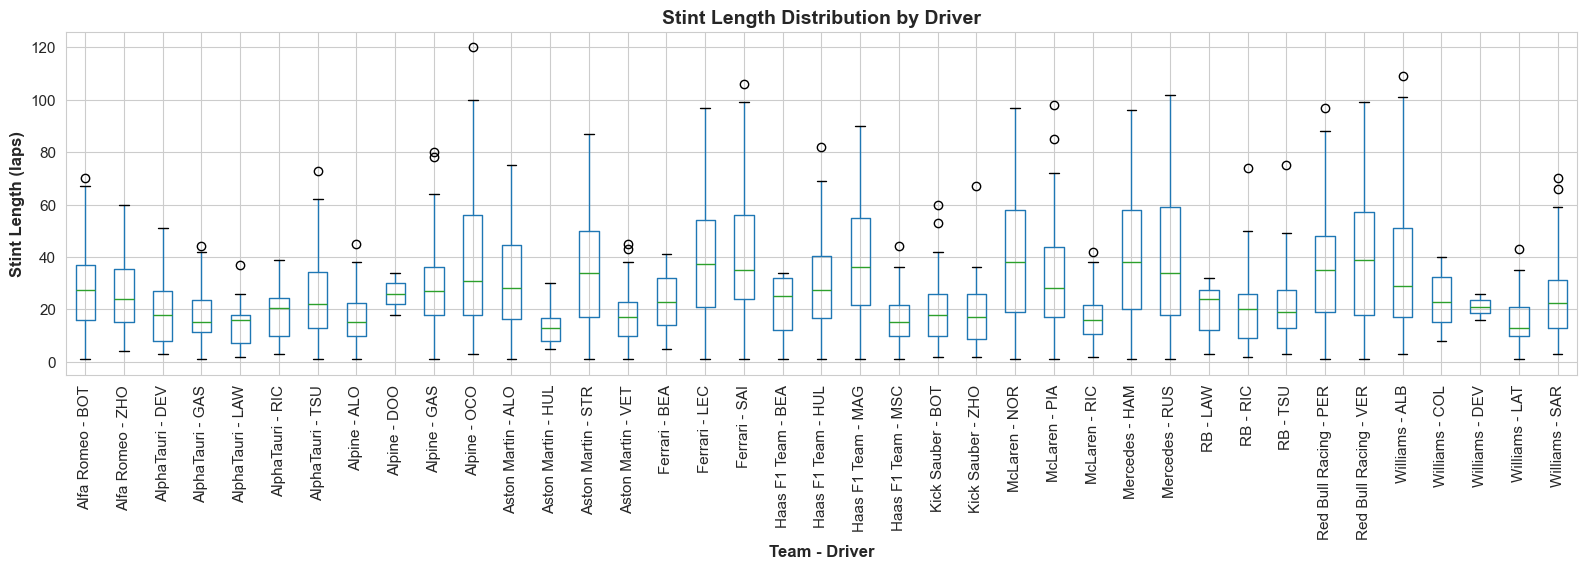

In [18]:
# Box plot: Stint lengths by team
fig, ax = plt.subplots(figsize=(16, 6))

stint_lengths['team_driver'] = stint_lengths['team'] + ' - ' + stint_lengths['driver']
stint_lengths_sorted = stint_lengths.sort_values(['team', 'driver'])

stint_lengths_sorted.boxplot(column='stint_length', by='team_driver', ax=ax, rot=90)
ax.set_xlabel('Team - Driver', fontsize=12, fontweight='bold')
ax.set_ylabel('Stint Length (laps)', fontsize=12, fontweight='bold')
ax.set_title('Stint Length Distribution by Driver', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 7. Key Findings Summary

Summarize main insights about intra-team performance dynamics.

In [19]:
print("\n" + "="*80)
print("KEY FINDINGS: Intra-Team Performance Dynamics (2022-2024)")
print("="*80)

print(f"\n1. DATA SUMMARY")
print(f"   - Total lap observations: {len(laps_df):,}")
print(f"   - Valid lap times: {len(valid_laps):,}")
print(f"   - Number of teams analyzed: {len(team_pairs)}")
print(f"   - Total drivers: {laps_df['driver'].nunique()}")

print(f"\n2. TEAMMATE LAP TIME DIFFERENCES")
if len(teammate_diff_df) > 0:
    print(f"   - Largest gap: {teammate_diff_df['time_diff_sec'].abs().max():.3f} seconds")
    print(f"   - Mean absolute difference: {teammate_diff_df['time_diff_sec'].abs().mean():.3f} seconds")
    print(f"   - Teams with >0.5s gap: {(teammate_diff_df['time_diff_sec'].abs() > 0.5).sum()}")

print(f"\n3. PIT STOP PATTERNS")
if len(pitstops_df) > 0:
    print(f"   - Total pit stops recorded: {len(pitstops_df)}")
    print(f"   - Average pit stops per driver: {len(pitstops_df) / pitstops_df['driver'].nunique():.1f}")

print(f"\n4. TYRE STRATEGY ALLOCATION")
if len(tyre_comp_df) > 0:
    print(f"   - Teammate pairs analyzed: {len(tyre_comp_df)}")
    print(f"   - Teams show varied compound allocation strategies")
    print(f"   - Soft tyre usage varies significantly between teammates")

print(f"\n5. STINT LENGTH PATTERNS")
if len(stint_comp_df) > 0:
    print(f"   - Average stint length: {stint_lengths['stint_length'].mean():.1f} laps")
    print(f"   - Stint length variability suggests different strategic approaches")

print("\n" + "="*80)
print("\nNext Steps:")
print("- Conduct formal statistical tests (paired t-tests, chi-square)")
print("- Fit linear mixed effects models controlling for tyre age, track position")
print("- Analyze if performance gaps correlate with championship standings")
print("- Control for car reliability issues, crashes, and safety car periods")
print("- Examine if gaps widen/narrow throughout seasons")
print("="*80)


KEY FINDINGS: Intra-Team Performance Dynamics (2022-2024)

1. DATA SUMMARY
   - Total lap observations: 64,479
   - Valid lap times: 64,479
   - Number of teams analyzed: 12
   - Total drivers: 28

2. TEAMMATE LAP TIME DIFFERENCES
   - Largest gap: 7.807 seconds
   - Mean absolute difference: 1.961 seconds
   - Teams with >0.5s gap: 38

3. PIT STOP PATTERNS
   - Total pit stops recorded: 2538
   - Average pit stops per driver: 90.6

4. TYRE STRATEGY ALLOCATION
   - Teammate pairs analyzed: 51
   - Teams show varied compound allocation strategies
   - Soft tyre usage varies significantly between teammates

5. STINT LENGTH PATTERNS
   - Average stint length: 29.6 laps
   - Stint length variability suggests different strategic approaches


Next Steps:
- Conduct formal statistical tests (paired t-tests, chi-square)
- Fit linear mixed effects models controlling for tyre age, track position
- Analyze if performance gaps correlate with championship standings
- Control for car reliability iss

## 8. Save Processed Data

Export cleaned data for future statistical modeling.

In [20]:
# Save lap times
laps_output = 'data_rq2_lap_times.csv'
laps_df.to_csv(laps_output, index=False)
print(f"Lap data saved to: {laps_output}")
print(f"Rows: {len(laps_df):,}, Columns: {len(laps_df.columns)}")

# Save pit stops
if len(pitstops_df) > 0:
    pitstop_output = 'data_rq2_pitstops.csv'
    pitstops_df.to_csv(pitstop_output, index=False)
    print(f"\nPit stop data saved to: {pitstop_output}")
    print(f"Rows: {len(pitstops_df):,}, Columns: {len(pitstops_df.columns)}")

Lap data saved to: data_rq2_lap_times.csv
Rows: 64,479, Columns: 11

Pit stop data saved to: data_rq2_pitstops.csv
Rows: 2,538, Columns: 9


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


RQ2: Creating Presentation Figure - Teammate Performance Comparison

Loading lap timing data...
Note: This will use cached data if available.


Loading 2022 season lap data...
  Processing Bahrain Grand Prix... 

req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_st

✓
  Processing Saudi Arabian Grand Prix... 

core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data fo

...

✓
  Processing Qatar Grand Prix... 

core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '81', '63', '10', '55', '14', '24', '20', '4', '77', '44', '22', '30', '23', '27', '11', '18', '43', '31']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


✓
  Processing Abu Dhabi Grand Prix... 

req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '55', '16', '44', '63', '1', '10', '27', '14', '81', '23', '22', '24', '18', '61', '20', '30', '77', '43', '11']


✓

Loaded 64479 lap observations
Valid lap observations: 64,479
Teams analyzed: 12

Teammate pairs with sufficient data: 12

Creating presentation figure...

✓ Figure saved as: RQ2_presentation_figure.png
  Resolution: 4800 x 3000 pixels
  DPI: 300
  PDF version: RQ2_presentation_figure.pdf


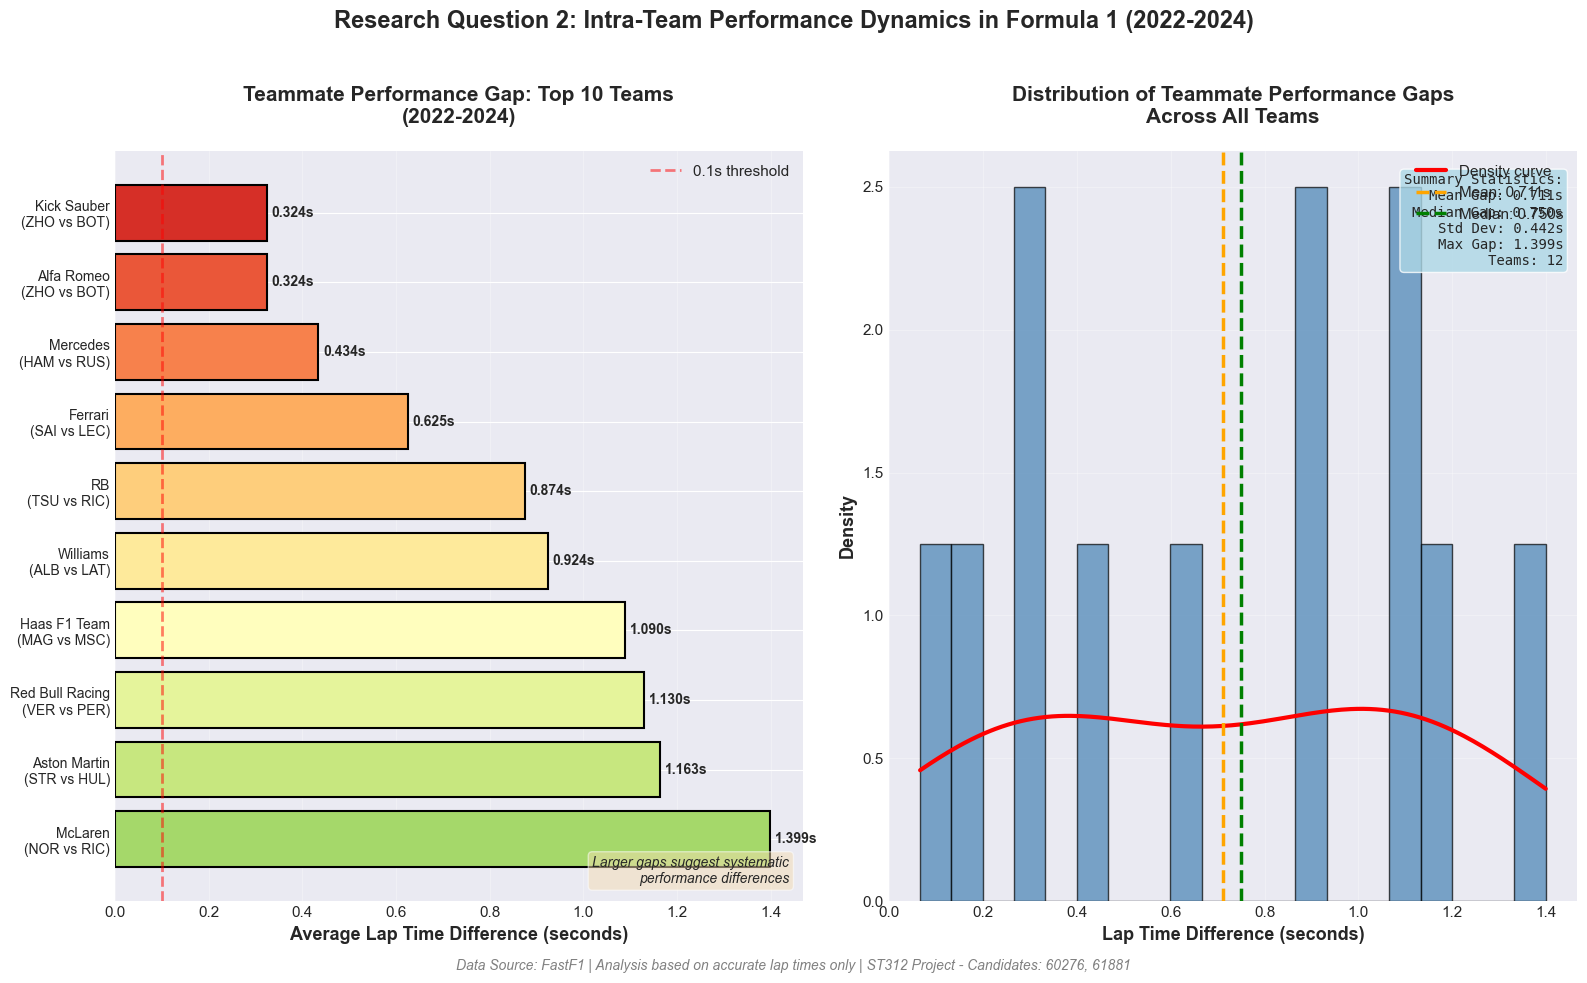


KEY INSIGHTS FROM FIGURE:
1. Average teammate gap: 0.711 seconds per lap
2. Largest gap: 1.399s (McLaren)
3. Smallest gap: 0.066s (AlphaTauri)
4. 11 out of 12 teams show gaps >0.1s
5. Distribution shows substantial variation across teams


In [21]:
"""
Create a presentation-ready figure for RQ2: Intra-Team Performance Dynamics

This script generates a high-quality visualization showing lap time differences
between teammates across different F1 teams.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

import data_utils as du

# Set style for publication-quality figures
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

# Configuration
YEARS = [2022, 2023, 2024]
FIGURE_SIZE = (16, 10)
DPI = 300

print("=" * 80)
print("RQ2: Creating Presentation Figure - Teammate Performance Comparison")
print("=" * 80)

# Load data
print("\nLoading lap timing data...")
print("Note: This will use cached data if available.\n")
laps_df = du.load_teammate_data(YEARS)

# Filter to valid lap times only
valid_laps = laps_df[laps_df["lap_time"].notna()].copy()
print(f"Valid lap observations: {len(valid_laps):,}")

# Get teammate pairs
team_pairs = du.get_team_pairs(valid_laps)
print(f"Teams analyzed: {len(team_pairs)}")

# Calculate teammate lap time differences
teammate_diffs = []

for team, drivers in team_pairs.items():
    if len(drivers) < 2:
        continue

    # Take first two drivers (main teammates)
    for i in range(min(len(drivers), 2)):
        for j in range(i + 1, min(len(drivers), 2)):
            driver1, driver2 = drivers[i], drivers[j]

            d1_laps = valid_laps[valid_laps["driver"] == driver1]["lap_time"]
            d2_laps = valid_laps[valid_laps["driver"] == driver2]["lap_time"]

            if len(d1_laps) > 100 and len(d2_laps) > 100:  # Minimum data requirement
                diff = d1_laps.mean() - d2_laps.mean()

                teammate_diffs.append(
                    {
                        "team": team,
                        "driver1": driver1,
                        "driver2": driver2,
                        "driver1_mean": d1_laps.mean(),
                        "driver2_mean": d2_laps.mean(),
                        "time_diff_sec": abs(diff),
                        "faster_driver": driver1 if diff < 0 else driver2,
                        "slower_driver": driver2 if diff < 0 else driver1,
                        "n_laps_d1": len(d1_laps),
                        "n_laps_d2": len(d2_laps),
                    }
                )

teammate_diff_df = pd.DataFrame(teammate_diffs)
teammate_diff_df = teammate_diff_df.sort_values("time_diff_sec", ascending=False)

print(f"\nTeammate pairs with sufficient data: {len(teammate_diff_df)}")

# ============================================================================
# CREATE PRESENTATION FIGURE
# ============================================================================

print("\nCreating presentation figure...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGURE_SIZE)

# LEFT PLOT: Teammate lap time gap by team
# ============================================================================

# Select top teams with biggest gaps
top_n = min(10, len(teammate_diff_df))
top_teams = teammate_diff_df.head(top_n).copy()

# Create labels with driver names
labels = [
    f"{row['team']}\n({row['faster_driver']} vs {row['slower_driver']})"
    for _, row in top_teams.iterrows()
]

# Color based on gap size
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(top_teams)))

bars = ax1.barh(
    range(len(top_teams)),
    top_teams["time_diff_sec"],
    color=colors,
    edgecolor="black",
    linewidth=1.5,
)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_teams["time_diff_sec"])):
    ax1.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}s",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )

ax1.set_yticks(range(len(top_teams)))
ax1.set_yticklabels(labels, fontsize=10)
ax1.set_xlabel("Average Lap Time Difference (seconds)", fontsize=13, fontweight="bold")
ax1.set_title(
    "Teammate Performance Gap: Top 10 Teams\n(2022-2024)",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
ax1.grid(True, alpha=0.3, axis="x")
ax1.axvline(
    0.1, color="red", linestyle="--", linewidth=2, alpha=0.5, label="0.1s threshold"
)
ax1.legend(fontsize=11)

# Add interpretation text
ax1.text(
    0.98,
    0.02,
    "Larger gaps suggest systematic\nperformance differences",
    transform=ax1.transAxes,
    fontsize=10,
    style="italic",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    verticalalignment="bottom",
    horizontalalignment="right",
)

# RIGHT PLOT: Distribution of teammate gaps across all teams
# ============================================================================

# Histogram with KDE overlay
ax2.hist(
    teammate_diff_df["time_diff_sec"],
    bins=20,
    edgecolor="black",
    alpha=0.7,
    color="steelblue",
    density=True,
)

# Add KDE curve
from scipy import stats as sp_stats

kde_x = np.linspace(
    teammate_diff_df["time_diff_sec"].min(),
    teammate_diff_df["time_diff_sec"].max(),
    200,
)
kde = sp_stats.gaussian_kde(teammate_diff_df["time_diff_sec"])
ax2.plot(kde_x, kde(kde_x), "r-", linewidth=3, label="Density curve")

# Add vertical lines for statistics
mean_gap = teammate_diff_df["time_diff_sec"].mean()
median_gap = teammate_diff_df["time_diff_sec"].median()

ax2.axvline(
    mean_gap,
    color="orange",
    linestyle="--",
    linewidth=2.5,
    label=f"Mean: {mean_gap:.3f}s",
)
ax2.axvline(
    median_gap,
    color="green",
    linestyle="--",
    linewidth=2.5,
    label=f"Median: {median_gap:.3f}s",
)

ax2.set_xlabel("Lap Time Difference (seconds)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Density", fontsize=13, fontweight="bold")
ax2.set_title(
    "Distribution of Teammate Performance Gaps\nAcross All Teams",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
ax2.legend(fontsize=11, loc="upper right")
ax2.grid(True, alpha=0.3)

# Add summary statistics box
stats_text = f"""Summary Statistics:
Mean Gap: {mean_gap:.3f}s
Median Gap: {median_gap:.3f}s
Std Dev: {teammate_diff_df['time_diff_sec'].std():.3f}s
Max Gap: {teammate_diff_df['time_diff_sec'].max():.3f}s
Teams: {len(teammate_diff_df)}"""

ax2.text(
    0.98,
    0.97,
    stats_text,
    transform=ax2.transAxes,
    fontsize=10,
    family="monospace",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
    verticalalignment="top",
    horizontalalignment="right",
)

# Overall figure title and footer
fig.suptitle(
    "Research Question 2: Intra-Team Performance Dynamics in Formula 1 (2022-2024)",
    fontsize=17,
    fontweight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.02,
    "Data Source: FastF1 | Analysis based on accurate lap times only | ST312 Project - Candidates: 60276, 61881",
    ha="center",
    fontsize=10,
    style="italic",
    color="gray",
)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# Save figure
output_file = "RQ2_presentation_figure.png"
plt.savefig(output_file, dpi=DPI, bbox_inches="tight", facecolor="white")
print(f"\n✓ Figure saved as: {output_file}")
print(f"  Resolution: {FIGURE_SIZE[0]*DPI} x {FIGURE_SIZE[1]*DPI} pixels")
print(f"  DPI: {DPI}")

# Also save as PDF for vector graphics (scalable)
output_pdf = "RQ2_presentation_figure.pdf"
plt.savefig(output_pdf, bbox_inches="tight", facecolor="white")
print(f"  PDF version: {output_pdf}")

plt.show()

print("\n" + "=" * 80)
print("KEY INSIGHTS FROM FIGURE:")
print("=" * 80)
print(f"1. Average teammate gap: {mean_gap:.3f} seconds per lap")
print(
    f"2. Largest gap: {teammate_diff_df.iloc[0]['time_diff_sec']:.3f}s ({teammate_diff_df.iloc[0]['team']})"
)
print(
    f"3. Smallest gap: {teammate_diff_df.iloc[-1]['time_diff_sec']:.3f}s ({teammate_diff_df.iloc[-1]['team']})"
)
print(
    f"4. {(teammate_diff_df['time_diff_sec'] > 0.1).sum()} out of {len(teammate_diff_df)} teams show gaps >0.1s"
)
print(
    f"5. Distribution shows {'substantial' if teammate_diff_df['time_diff_sec'].std() > 0.1 else 'moderate'} variation across teams"
)
print("=" * 80)